### 4. Model Development

### `04_model_development.ipynb`

Fall Detection - Model Development

1. Loading and Preparing Data...
Loading normalized features from: outputs\features\normalized_features.csv
Loaded feature data with 143 samples and 74 features

Feature dataset information:
Shape: (143, 74)
Labels: {'activity': 99, 'workout': 38, 'fall': 6}

Features with missing values: 1
Top features with missing values:
has_impact    99
dtype: int64

2. Data Preprocessing and Feature Selection...
Converting multi-class labels to binary (fall vs. non-fall)
Labels after conversion: {0: 137, 1: 6}
Dropping 1 features with >50% missing values
Remaining features: 70
Feature list:
fps, duration, right_elbow_mean, right_elbow_min, right_elbow_max, right_elbow_range, right_elbow_max_velocity, left_elbow_mean, left_elbow_min, left_elbow_max, left_elbow_range, left_elbow_max_velocity, right_knee_mean, right_knee_min, right_knee_max, right_knee_range, right_knee_max_velocity, left_knee_mean, left_knee_min, left_knee_max, left_knee_range, left_knee_max_veloc

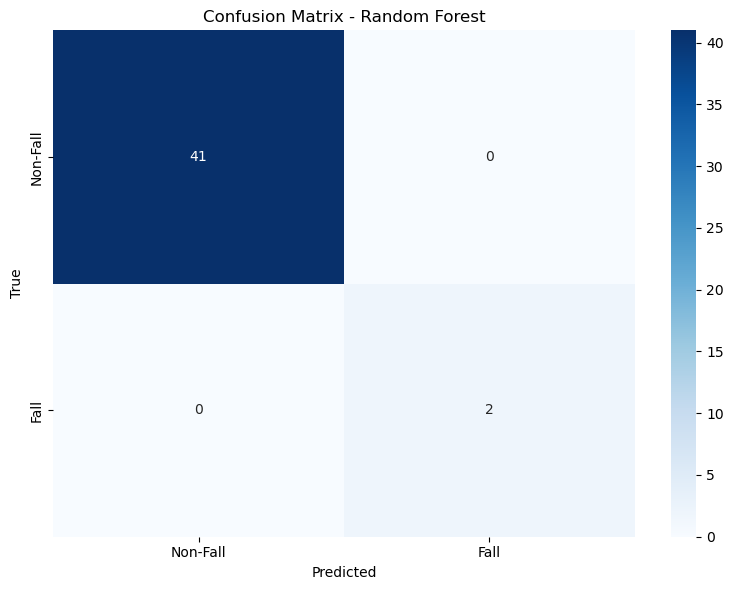

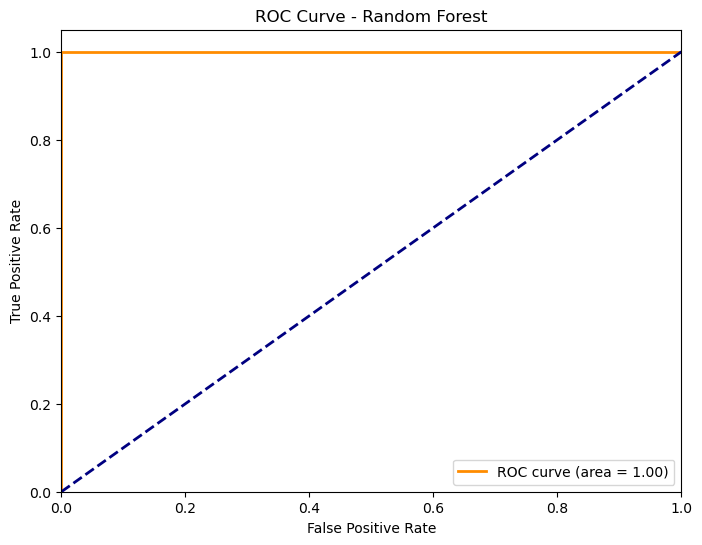


Classification Report:
              precision    recall  f1-score   support

    Non-Fall       1.00      1.00      1.00        41
        Fall       1.00      1.00      1.00         2

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43


9. Feature Importance Analysis...


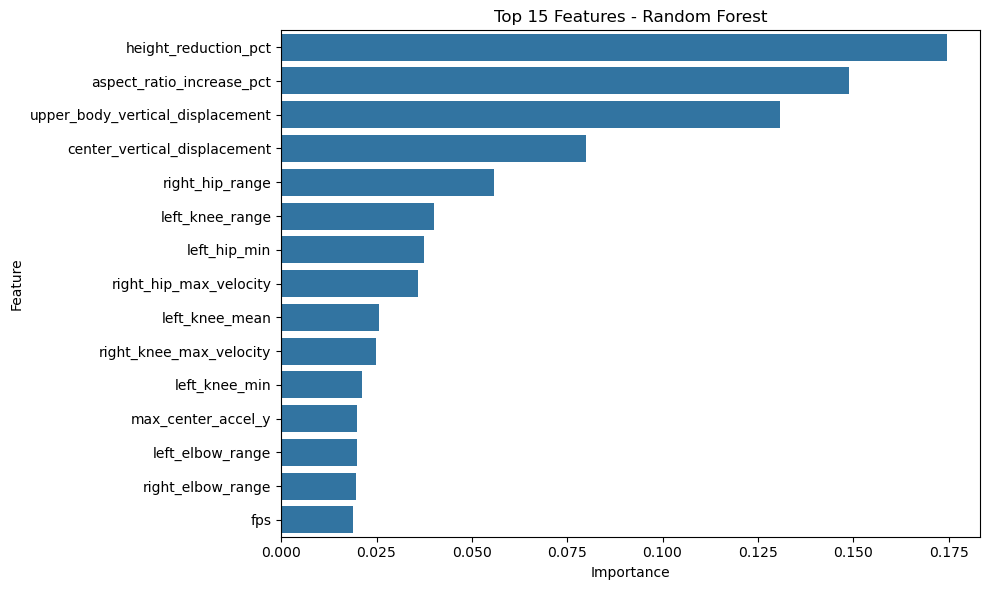

Top 10 most important features:
                         Feature  Importance
            height_reduction_pct    0.174511
       aspect_ratio_increase_pct    0.148929
upper_body_vertical_displacement    0.130679
    center_vertical_displacement    0.079948
                 right_hip_range    0.055833
                 left_knee_range    0.040000
                    left_hip_min    0.037585
          right_hip_max_velocity    0.035798
                  left_knee_mean    0.025732
         right_knee_max_velocity    0.024946

10. Saving Best Model...
Model saved to outputs\models\fall_detection_model.pkl
Model info saved to outputs\models\model_info.json

11. Example Code for Using the Model:

import pickle
import pandas as pd

# Load the model
with open('outputs/models/fall_detection_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Example features (replace with actual feature values)
features = {
    'right_elbow_mean': 120.5,
    'right_elbow_min': 90.2,
    # Add all required feat

In [1]:
# 04_model_development.ipynb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer

import warnings
warnings.filterwarnings('ignore')

# Set paths
ROOT_DIR = Path(".")
FEATURES_DIR = ROOT_DIR / "outputs" / "features"
MODELS_DIR = ROOT_DIR / "outputs" / "models"
os.makedirs(MODELS_DIR, exist_ok=True)

print("Fall Detection - Model Development")

# 1. Load and Prepare Data
print("\n1. Loading and Preparing Data...")

def load_feature_data():
    """Load feature data from CSV"""
    # Try to load normalized features first
    normalized_file = FEATURES_DIR / "normalized_features.csv"
    if normalized_file.exists():
        print(f"Loading normalized features from: {normalized_file}")
        df = pd.read_csv(normalized_file)
    else:
        # Fall back to raw features
        raw_file = FEATURES_DIR / "features_for_modeling.csv"
        if raw_file.exists():
            print(f"Loading raw features from: {raw_file}")
            df = pd.read_csv(raw_file)
        else:
            # No pre-processed features found, check for JSON
            json_file = FEATURES_DIR / "all_features.json"
            if json_file.exists():
                print(f"Loading features from JSON: {json_file}")
                with open(json_file, 'r') as f:
                    features = json.load(f)
                
                # Convert to DataFrame
                rows = []
                for item in features:
                    row = {'label': item['metadata']['label']}
                    # Add all numeric features
                    for category in ['joint_angles', 'vertical_motion', 'impact', 'collapse']:
                        if category in item:
                            for k, v in item[category].items():
                                if isinstance(v, (int, float)) and not isinstance(v, bool):
                                    row[k] = v
                                elif isinstance(v, bool):
                                    row[k] = int(v)
                    rows.append(row)
                df = pd.DataFrame(rows)
            else:
                raise FileNotFoundError("No feature data found!")
    
    print(f"Loaded feature data with {df.shape[0]} samples and {df.shape[1]} features")
    return df

# Load feature data
feature_df = load_feature_data()

# Display data info
print("\nFeature dataset information:")
print(f"Shape: {feature_df.shape}")
print(f"Labels: {feature_df['label'].value_counts().to_dict()}")

# Display missing values
missing_values = feature_df.isna().sum()
print(f"\nFeatures with missing values: {missing_values[missing_values > 0].shape[0]}")
if missing_values[missing_values > 0].shape[0] > 0:
    print("Top features with missing values:")
    print(missing_values[missing_values > 0].sort_values(ascending=False).head())

# 2. Data Preprocessing and Feature Selection
print("\n2. Data Preprocessing and Feature Selection...")

# Separate features and labels
X = feature_df.drop(['label', 'video_path', 'data_type', 'file_path'], axis=1, errors='ignore')
y = feature_df['label']

# Convert labels to binary for fall detection
if len(y.unique()) > 2:
    print(f"Converting multi-class labels to binary (fall vs. non-fall)")
    y = y.apply(lambda x: 1 if x == 'fall' else 0)
    print(f"Labels after conversion: {y.value_counts().to_dict()}")
elif y.dtype != int:
    # Map string labels to integers if needed
    label_map = {'fall': 1, 'workout': 0, 'activity': 0}
    y = y.map(label_map)
    print(f"Labels mapped to integers: {y.value_counts().to_dict()}")

# Feature selection - remove features with too many missing values
missing_threshold = 0.5
features_to_drop = X.columns[X.isna().mean() > missing_threshold]
if len(features_to_drop) > 0:
    print(f"Dropping {len(features_to_drop)} features with >50% missing values")
    X = X.drop(features_to_drop, axis=1)

# Print remaining features
print(f"Remaining features: {X.shape[1]}")
print("Feature list:")
print(", ".join(X.columns.tolist()))

# 3. Data Splitting
print("\n3. Splitting Data into Train and Test Sets...")

# Check if we have enough data for a train/test split
if X.shape[0] < 10:
    print("Warning: Very small dataset - using cross-validation only")
    X_train, X_test, y_train, y_test = X, X, y, y
    use_cv_only = True
else:
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    use_cv_only = False
    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

# 4. Define Model Pipeline
print("\n4. Defining Model Pipeline...")

# Create a pipeline with preprocessing and model
def create_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

# 5. Define Fall Detection Specific Metrics
print("\n5. Defining Fall Detection Metrics...")

def fall_detection_score(y_true, y_pred):
    """
    Custom scoring function prioritizing recall for fall detection
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        
    Returns:
        Weighted F1 score with emphasis on recall for fall class
    """
    # Calculate precision and recall for fall class (positive class)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    
    # Calculate weighted F1 score (beta=2 gives more weight to recall)
    beta = 2
    if precision + recall == 0:
        return 0
    f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    return f_beta

# Create a scorer for GridSearchCV
fall_scorer = make_scorer(fall_detection_score)

# 6. Model Training and Evaluation
print("\n6. Training and Evaluating Models...")

# Define models to evaluate
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=42)
}

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5]
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7],
        'classifier__weights': ['uniform', 'distance']
    },
    'Neural Network': {
        'classifier__hidden_layer_sizes': [(10,), (50,), (10, 10)],
        'classifier__alpha': [0.0001, 0.001]
    }
}

# For very small datasets, use simpler parameters
if X.shape[0] < 10:
    for model_name in param_grids:
        for param in param_grids[model_name]:
            param_grids[model_name][param] = [param_grids[model_name][param][0]]

# Results storage
results = {}
best_models = {}

# Cross-validation strategy
if X.shape[0] < 10:
    cv = StratifiedKFold(n_splits=min(3, X.shape[0]), shuffle=True, random_state=42)
    print("Using leave-one-out style cross-validation due to small dataset")
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    print("Using 5-fold cross-validation")

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Create pipeline
    pipeline = create_pipeline(model)
    
    # Define grid search
    grid_search = GridSearchCV(
        pipeline,
        param_grids[model_name],
        cv=cv,
        scoring=fall_scorer,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit model
    grid_search.fit(X_train, y_train)
    
    # Get best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    
    # Make predictions
    if use_cv_only:
        # For very small datasets, report cross-validation scores
        results[model_name] = {
            'cv_score': grid_search.best_score_,
            'best_params': grid_search.best_params_
        }
        print(f"Cross-validation score: {grid_search.best_score_:.4f}")
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        # For larger datasets, evaluate on test set
        y_pred = best_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        custom_score = fall_detection_score(y_test, y_pred)
        
        # Store results
        results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'fall_detection_score': custom_score,
            'best_params': grid_search.best_params_
        }
        
        # Print results
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"Fall Detection Score: {custom_score:.4f}")
        print(f"Best parameters: {grid_search.best_params_}")

# 7. Select Best Model
print("\n7. Selecting Best Model...")

if use_cv_only:
    # For small datasets, select based on cross-validation score
    best_model_name = max(results, key=lambda x: results[x]['cv_score'])
    best_score = results[best_model_name]['cv_score']
    print(f"Best model: {best_model_name} (CV Score: {best_score:.4f})")
else:
    # For larger datasets, select based on fall detection score
    best_model_name = max(results, key=lambda x: results[x]['fall_detection_score'])
    best_score = results[best_model_name]['fall_detection_score']
    print(f"Best model: {best_model_name} (Fall Detection Score: {best_score:.4f})")

# Get the best model
best_model = best_models[best_model_name]

# 8. Final Model Evaluation
print("\n8. Final Model Evaluation...")

if not use_cv_only:
    # Confusion Matrix
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Fall', 'Fall'],
                yticklabels=['Non-Fall', 'Fall'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'confusion_matrix.png')
    plt.show()
    
    # ROC Curve
    y_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc="lower right")
    plt.savefig(MODELS_DIR / 'roc_curve.png')
    plt.show()
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Fall', 'Fall']))

# 9. Feature Importance Analysis
print("\n9. Feature Importance Analysis...")

# Check if the model has feature importances
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    # Get feature importances
    feature_importances = best_model.named_steps['classifier'].feature_importances_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'feature_importance.png')
    plt.show()
    
    print("Top 10 most important features:")
    print(importance_df.head(10).to_string(index=False))
elif hasattr(best_model.named_steps['classifier'], 'coef_'):
    # For linear models, use coefficients
    coef = best_model.named_steps['classifier'].coef_[0]
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coef
    }).sort_values('Coefficient', ascending=False)
    
    # Plot top features by absolute coefficient
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=importance_df.head(15))
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'feature_importance.png')
    plt.show()
    
    print("Top 10 most influential features:")
    print(importance_df[['Feature', 'Coefficient']].head(10).to_string(index=False))
else:
    print("Feature importance not available for this model type")

# 10. Save Best Model
print("\n10. Saving Best Model...")

# Save model to file
model_file = MODELS_DIR / 'fall_detection_model.pkl'
with open(model_file, 'wb') as f:
    pickle.dump(best_model, f)

# Save simplified model info (avoid serialization issues)
model_info = {
    'model_name': best_model_name,
    'features': X.columns.tolist(),
    'metrics': {
        k: float(v) if isinstance(v, (np.integer, np.floating)) else v
        for k, v in results[best_model_name].items()
        if k != 'best_params'  # Skip complex parameters
    },
    'num_features': len(X.columns),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
}

info_file = MODELS_DIR / 'model_info.json'
with open(info_file, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"Model saved to {model_file}")
print(f"Model info saved to {info_file}")

# 11. Example Prediction Code
print("\n11. Example Code for Using the Model:")

example_code = '''
import pickle
import pandas as pd

# Load the model
with open('outputs/models/fall_detection_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Example features (replace with actual feature values)
features = {
    'right_elbow_mean': 120.5,
    'right_elbow_min': 90.2,
    # Add all required features here
}

# Convert to DataFrame
X_new = pd.DataFrame([features])

# Make prediction
prediction = model.predict(X_new)[0]
probability = model.predict_proba(X_new)[0, 1]  # Probability of fall

print(f"Prediction: {'Fall' if prediction == 1 else 'Non-Fall'}")
print(f"Fall probability: {probability:.2f}")
'''

print(example_code)

print("\nModel development completed!")